<div align="center">
<span style="font-size: 2.3em;">Halo Model Exclusion Comparison</span>
<br>
<span style="font-size: 1.1em; color: gray;">Averaged-posterior 90% exclusions for realistic and extreme halo models</span>
</div>

## Overview

This notebook produces the exclusion comparison figures for two sets of halo models,
in a single consistent style:

- **realistic**: SHM, SHM++, LMC, and their combined classifier
- **extreme**: SHMhigh, SHMlow, SHM reference, and the combined SHMhigh$\cup$SHMlow classifier

For every model the 90% exclusion is derived from the **averaged posterior** over many
background realizations (as in `sbi_exclusion_posteriors_average`): we average the
posterior grids, then extract the median upper limit as the 90% HPD boundary marginalized
over mass. Switch between the two figure sets with the `MODEL_SET` flag in the config cell.

## 1. Setup

In [1]:
import os
import importlib

import numpy as np
import torch
import matplotlib.pyplot as plt

desired_root_name = "xenon-sbi"
while os.path.basename(os.getcwd()) != desired_root_name:
    os.chdir(os.path.abspath(os.path.join(os.getcwd(), "..")))

import utils.posteriors as posteriors
importlib.reload(posteriors)

from configs.config import PARAM_RANGES, load_model_s1s2
from utils.posteriors import (
    compute_hpd_contours,
    generate_null_spectrum_s1s2,
    posterior_grid,
    _cp_to_sigma_p,
)
from utils.processing import load_s1s2_valloader

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300

### Configuration

In [2]:
# ==========================================================
# Select which figure to produce: "realistic" or "extreme"
# ==========================================================
MODEL_SET = "realistic"

modelname = "S1S2_signal_bg"
datatag   = "low"
n_train   = 300_000
bins      = 10
mu_bg    = 150

n_eval          = 5000
n_realizations  = 2000     # background realizations to average over
posteriorbins   = 150

logm_range = PARAM_RANGES[datatag]["logm_range"]
logcp_range = PARAM_RANGES[datatag]["logcp_range"]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
signal_type = "signal_only" if mu_bg == 0 else f"signal_bg_mu{mu_bg:.0f}"

# --- model paths, labels, colors, and reference model per set ---
if MODEL_SET == "realistic":
    MODELS = {
        "shm":      dict(label="SHM",      path=f"models/xenon/{signal_type}/shm/{modelname}_bins{bins}_n{n_train}_shm.pt"),
        "shmpp":    dict(label="SHM++",    path=f"models/xenon/{signal_type}/shmpp/{modelname}_bins{bins}_n{n_train}_shmpp.pt"),
        "lmc":      dict(label="LMC",      path=f"models/xenon/{signal_type}/lmc/{modelname}_bins{bins}_n{n_train}_lmc.pt"),
        "combined": dict(label="Combined", path=f"models/xenon/{signal_type}/combined/shm_shmpp_lmc/{modelname}_bins{bins}_n{n_train}_shm_shmpp_lmc.pt"),
    }
    REF = "shm"                       # reference for the relative-difference panel
    SIGNAL_HALO = "shm"               # signal library used to build the validation loader
    SAVENAME = "figures/realistic_halo_comparison_medians.pdf"
    # color scheme reused from the halo-model figures (realistic palette)
    COLORS = {
        "shm":      "#67000d",  # dark red
        "shmpp":    "#e34a33",  # orange-red
        "lmc":      "#dfa81e",  # gold
        "combined": "#525252",  # neutral gray
    }
elif MODEL_SET == "extreme":
    MODELS = {
        "x1":    dict(label="SHMhigh",  path=f"models/xenon/{signal_type}/x1/{modelname}_bins{bins}_n{n_train}_x1.pt"),
        "x2":    dict(label="SHMlow",   path=f"models/xenon/{signal_type}/x2/{modelname}_bins{bins}_n{n_train}_x2.pt"),
        "shm":   dict(label="SHM",      path=f"models/xenon/{signal_type}/shm/{modelname}_bins{bins}_n{n_train}_shm.pt"),
        "x1_x2": dict(label="Combined", path=f"models/xenon/{signal_type}/combined/x1_x2/{modelname}_bins{bins}_n{n_train}_x1_x2.pt"),
    }
    REF = "shm"
    SIGNAL_HALO = "x1"
    SAVENAME = "figures/extreme_halo_comparison_medians.pdf"
    # extreme palette: blues for high/low, red reference, neutral combined
    COLORS = {
        "x1":    "#2171b5",  # SHMhigh, blue
        "x2":    "#6baed6",  # SHMlow, light blue
        "shm":   "#67000d",  # SHM reference, dark red
        "x1_x2": "#525252",  # combined, neutral gray
    }
else:
    raise ValueError("MODEL_SET must be 'realistic' or 'extreme'")

print(f"Model set: {MODEL_SET}")
print(f"Averaging over {n_realizations} background realizations")

Model set: realistic
Averaging over 2000 background realizations


### Load models and background pool

In [3]:
models = {}
for key, spec in MODELS.items():
    print(f"Loading {spec['label']:9s} <- {spec['path']}")
    m, _ = load_model_s1s2(spec["path"], bins=bins, modelname=modelname,
                           device=device, print_arch=False)
    models[key] = m

SIGNAL_PT = f"data/datasets/xenon/s1s2/pt/s1s2_n{n_train}_{SIGNAL_HALO}.pt"
bg_CSV   = "data/datasets/xenon/s1s2/ers/s1s2_ers.csv"
val_loader, bg_events = load_s1s2_valloader(SIGNAL_PT, bg_CSV, mu_bg=mu_bg,
                                             bins=bins, n_eval=n_eval)
print(f"\nBackground pool: {bg_events.shape}")

Loading SHM       <- models/xenon/signal_bg_mu150/shm/S1S2_signal_bg_bins10_n300000_shm.pt
Loading SHM++     <- models/xenon/signal_bg_mu150/shmpp/S1S2_signal_bg_bins10_n300000_shmpp.pt
Loading LMC       <- models/xenon/signal_bg_mu150/lmc/S1S2_signal_bg_bins10_n300000_lmc.pt
Loading Combined  <- models/xenon/signal_bg_mu150/combined/shm_shmpp_lmc/S1S2_signal_bg_bins10_n300000_shm_shmpp_lmc.pt
Validation pairs: 10,000

Background pool: (9027194, 2)


## 2. Averaged-Posterior Exclusion

For each model we average the posterior over `n_realizations` background realizations,
exactly as in `sbi_exclusion_posteriors_average`. The 90% exclusion is the upper $c_p$
edge of the 90% HPD region of this averaged posterior. At low masses the HPD region is
open at the top of the prior range, so the curve leaves the figure there rather than
producing a spurious limit.

In [4]:
def average_background_posteriors(
    background_events, mu_bg, bins, model,
    logm_range, logcp_range, device,
    n_realizations=2000, posteriorbins=150, seed_offset=0,
):
    """Average posterior grids across many background-only realizations.

    Identical to the procedure in sbi_exclusion_posteriors_average: build a null
    (background-only) spectrum for each seed, evaluate the posterior grid, then
    average and normalize over the grid.
    """
    posterior_list = []
    logm_vals = logcp_vals = None
    for seed in np.arange(n_realizations) + seed_offset:
        null_spectrum = generate_null_spectrum_s1s2(
            background_events=background_events, mu_bg=mu_bg,
            s1_bins=bins, s2_bins=bins, rng_seed=int(seed),
        )
        posterior, lm, lc = posterior_grid(
            null_spectrum, logm_range=logm_range, logcp_range=logcp_range,
            posteriorbins=posteriorbins, model=model, device=device,
        )
        posterior_list.append(posterior.detach().cpu().numpy())
        if logm_vals is None:
            logm_vals, logcp_vals = lm, lc
    avg = np.mean(np.stack(posterior_list, axis=0), axis=0)
    dlogm, dlogcp = logm_vals[1] - logm_vals[0], logcp_vals[1] - logcp_vals[0]
    avg /= avg.sum() * dlogm * dlogcp
    return avg, logm_vals, logcp_vals


def exclusion_from_hpd_threshold(avg_post, logm_vals, logcp_vals, cl=0.90):
    """Exclusion curve from the 90% HPD *threshold* of the averaged posterior.

    Mirrors sbi_exclusion_posteriors_average, but extracts a smooth upper limit:
    find the density threshold enclosing `cl` of the total probability, then at
    each mass take the highest c_p whose posterior density still exceeds that
    threshold. This is the upper edge of the same 90% HPD region traced by
    compute_hpd_contours, but evaluated directly on the grid (no polygon
    re-sampling), so it is smooth. Where the region is open at the top of the
    grid (low mass), the limit is left as NaN and the curve exits the figure.
    """
    post = np.asarray(avg_post, dtype=np.float64)
    dlogm = logm_vals[1] - logm_vals[0]
    dlogcp = logcp_vals[1] - logcp_vals[0]

    # global HPD density threshold: smallest level whose super-level set holds cl
    flat = np.sort(post.ravel())[::-1]
    cmass = np.cumsum(flat) * dlogm * dlogcp
    thr = flat[np.searchsorted(cmass, cl)]

    logcp_upper = np.full(logm_vals.shape, np.nan)
    for j in range(len(logm_vals)):
        inside = np.where(post[:, j] >= thr)[0]
        if inside.size == 0:
            continue
        top = inside.max()
        # if the region touches the top grid edge, the contour is open here
        # (low-mass, prior-dominated) -> leave NaN so the curve leaves the plot
        if top == len(logcp_vals) - 1:
            continue
        # linear interpolation of the crossing between `top` and `top+1`
        p0, p1 = post[top, j], post[top + 1, j]
        x0, x1 = logcp_vals[top], logcp_vals[top + 1]
        t = 0.0 if np.isclose(p0, p1) else np.clip((thr - p0) / (p1 - p0), 0.0, 1.0)
        logcp_upper[j] = x0 + t * (x1 - x0)

    m_vals = 10 ** logm_vals
    sigma = _cp_to_sigma_p(m_vals, 10 ** logcp_upper)
    return m_vals, sigma, logcp_upper

In [5]:
results = {}
for key in MODELS:
    print(f"Averaging posterior for {MODELS[key]['label']} ...")
    avg, lm, lc = average_background_posteriors(
        bg_events, mu_bg, bins, models[key],
        logm_range, logcp_range, device,
        n_realizations=n_realizations, posteriorbins=posteriorbins,
    )
    m_vals, sigma, logcp_upper = exclusion_from_hpd_threshold(avg, lm, lc, cl=0.90)
    results[key] = dict(m_vals=m_vals, sigma=sigma, logcp_upper=logcp_upper)
print("Done.")

Averaging posterior for SHM ...
Averaging posterior for SHM++ ...
Averaging posterior for LMC ...
Averaging posterior for Combined ...
Done.


## 3. Comparison Figure

Two stacked panels sharing the mass axis: exclusion curves on top, relative deviation
from the reference model below. The top panel is zoomed to the interesting cross-section
range so the model differences are visible; the bottom panel has no grid.

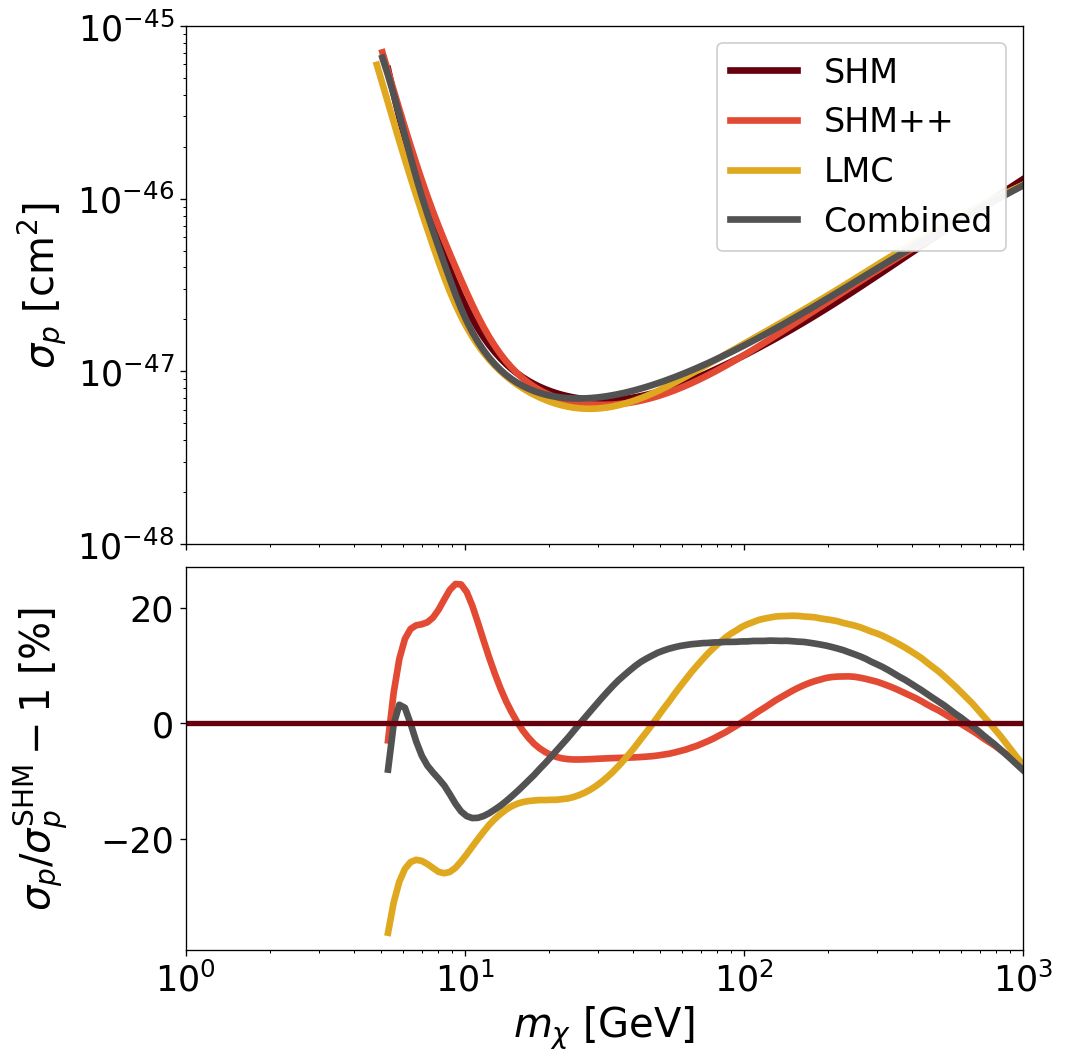

In [6]:
# ---- style constants (consistent across paper figures) ----
LABEL_SIZE  = 24
TICK_SIZE   = 21
LEGEND_SIZE = 20
LINEWIDTH   = 4

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(9, 10), sharex=True,
    gridspec_kw={"height_ratios": [1.35, 1], "hspace": 0.05},
)

# ---------- top panel: exclusion curves ----------
for key, res in results.items():
    valid = np.isfinite(res["sigma"])
    ax1.plot(res["m_vals"][valid], res["sigma"][valid],
             color=COLORS[key], linewidth=LINEWIDTH, label=MODELS[key]["label"])

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlim(1, 1000)

# zoom y-axis to the range where the curves actually live, so differences show
finite_sigma = np.concatenate([r["sigma"][np.isfinite(r["sigma"])] for r in results.values()])
ymin = 10 ** np.floor(np.log10(np.nanmin(finite_sigma)))
ymax = 10 ** np.ceil(np.log10(np.nanmax(finite_sigma)))
ax1.set_ylim(ymin, ymax)

ax1.set_ylabel(r"$\sigma_p$ [cm$^2$]", fontsize=LABEL_SIZE)
ax1.tick_params(axis="both", which="major", labelsize=TICK_SIZE)
ax1.legend(fontsize=LEGEND_SIZE, loc="upper right", framealpha=0.95)

# ---------- bottom panel: relative deviation from reference ----------
ref = results[REF]
ref_sigma = ref["sigma"]
for key, res in results.items():
    if key == REF:
        continue
    valid = np.isfinite(res["sigma"]) & np.isfinite(ref_sigma)
    rel = (res["sigma"][valid] - ref_sigma[valid]) / ref_sigma[valid] * 100
    ax2.plot(res["m_vals"][valid], rel,
             color=COLORS[key], linewidth=LINEWIDTH, label=MODELS[key]["label"])

ax2.axhline(0.0, color=COLORS[REF], linewidth=LINEWIDTH * 0.8)
ax2.set_xscale("log")
ax2.set_xlim(1, 1000)
ax2.set_xlabel(r"$m_\chi$ [GeV]", fontsize=LABEL_SIZE)
ax2.set_ylabel(r"$\sigma_p / \sigma_p^{\mathrm{" + MODELS[REF]["label"].replace("+", "") + r"}} - 1$ [%]",
               fontsize=LABEL_SIZE)
ax2.tick_params(axis="both", which="major", labelsize=TICK_SIZE)
# no grid on the lower panel

fig.align_ylabels([ax1, ax2])
#fig.savefig(SAVENAME, dpi=300, bbox_inches="tight")
#print(f"Saved {SAVENAME}")
plt.show()